# Week 2: Estimation (Individual)

In Week 1, you explored the system and developed a shared simulation framework.  
In Week 2, you will begin working individually to extract useful structure from the observed data.

## Objective

The internal state of the system is not directly observable. Your task is to design an approach that uses the available observations (and inputs) to construct a useful representation of the system.

There is **no single correct method**. You are expected to logically propose, clearly justify, and meaningfully evaluate your own approach.

## What does “estimation” mean here?

Depending on your design choices, your method need to aim to:

- identify patterns or structure in the observations,
- predict future observations,
- reconstruct hidden variables,
- compress the data into a lower-dimensional representation,
- extract features that can later be used for control.

## Tasks

You should:

1. **Define your objective**  
   Decide what you are trying to estimate and why it is useful.

2. **Design an approach**  
   Propose one or more methods based on your understanding of the system. Where possible, explore different approaches rather than relying on a single method, and compare their performance. Select the approach you consider most effective and justify your choice. Clearly state any assumptions you make.

3. **Implement your method**  
   Build on the Week 1 codebase. Test it on at least one simulation from Week 1. Your implementation does not need to be perfect, but it should be coherent and testable.

4. **Evaluate performance**  
   Use plots and quantitative measures to assess your method. Consider:
   - sensitivity to noise,
   - stability over time,
   - generalisation across different input patterns.

5. **Reflect on limitations**  
   Identify what your method does not capture and what could be improved.

## Guidance
- You may use both observations \(y(t)\) and inputs \(u(t)\). But inputs are not 100% reliable.
- You may use past data (history) if helpful.
- Simpler methods are acceptable if they are clearly justified and well analysed.
- A partially successful but well-explained approach is better than a complex but poorly understood one.

## Week 2 deliverable
**Deliverable:** Interim Report + code.
**Marks:** 20 individual marks.
**Due:** Friday 29 May at 9:00am BST. 

## Testing and evaluating your interface
On **Friday 29 May between 11am and 1pm**, the demonstrator will test your estimator to ensure that your interface meets the required specifications.  

This session is **compulsory** and important for your understanding and progression to the next stage of the project.

## Interim report guidance
Your interim report should be concise and focused, approximately **4 pages** in length, and must not exceed **5 pages total**, including figures and any appendix material.

The report should include:

- A brief description of the system and the simulations you have run,
- A summary of your Week 1 exploration,
- A clear description of your estimation approach,
- Initial results, with figures, demonstrating depth of analysis rather than broad but superficial coverage,
- A discussion of limitations and planned next steps.

The goal of the interim report is to demonstrate your understanding so far and to receive feedback ahead of the final stage.

## Connection to later work
Your estimation approach will form the basis for your control strategy in Week 3.  
Think ahead about how your representation could be used to influence the system.

## Estimation interface

To make testing and evaluation consistent across students, all estimation methods must follow the interface below.

You are free to implement any estimation strategy internally, provided that your function:
- accepts observations as input,
- returns estimated latent states and estimated inputs,
- and preserves the required function signature.

### Important:
- Do not change the function signature of `estimate_latent_and_input`. The demonstrator will call this function to evaluate your solution during the Week 2 evaluation session.
- You may implement any logic inside the function, but it must return:
   1. estimated latent states with shape (Timepoints, LatentDim)
   2. estimated inputs with shape (Timepoints, InputDim)
- If your method uses additional hyperparameters, use partial functions or wrapper functions to fix them before submission. You will not have the opportunity to adjust hyperparameters during the test. Automatic parameter tuning is welcome.


In [62]:
import numpy as np
from Estimator import estimate_latent_and_input


In [65]:
T,N = 100, 20
Y = np.random.randn(T,N)
t,n = estimate_latent_and_input()
print(t.shape)
print(n.shape)

(100, 3)
(100, 2)


In [66]:
Y1 = np.random.randn(1, 20)
lat, inp = estimate_latent_and_input(Y1, 3, 2)
print(lat.shape, inp.shape, " 应该是 (1,3) (1,2) 且不报错")

(1, 3) (1, 2)  应该是 (1,3) (1,2) 且不报错


In [67]:
Y2 = np.random.randn(2, 20)
lat, inp = estimate_latent_and_input(Y2, 3, 2)
print(lat.shape, inp.shape, " 应该是 (2,3) (2,2)")

(2, 3) (2, 2)  应该是 (2,3) (2,2)


In [68]:
Y = np.random.randn(50, 20)
Y[3, 5] = np.nan       # 故意塞坏值
Y[10, 0] = np.inf
Y[-1, -1] = -np.inf
lat, inp = estimate_latent_and_input(Y, 3, 2)
print("含坏值仍输出有限值:", np.all(np.isfinite(lat)) and np.all(np.isfinite(inp)))

含坏值仍输出有限值: True


In [69]:
Y = np.ones((50, 10))    # 所有元素全是 1
lat, inp = estimate_latent_and_input(Y, 2, 1)
print(lat.shape, " 应该是 (50, 2),不报错")

(50, 2)  应该是 (50, 2),不报错


In [70]:
Y = np.random.randn(50, 3)         # 只有 3 个神经元
lat, inp = estimate_latent_and_input(Y, LatentDim=8, InputDim=2)  # 却要 8 维
print(lat.shape, " 应该是 (50, 8),后几维可能很小或为 0")

(50, 8)  应该是 (50, 8),后几维可能很小或为 0


In [72]:
for bad in [0, -1, 2.5, "三"]:
    try:
        estimate_latent_and_input(np.random.randn(50, 10), bad, 2)
        print(f"  LatentDim={bad}: 没报错 ← 有 bug!")
    except Exception as e:
        print(f"  LatentDim={bad}: 正确报错 ({type(e).__name__})")

  LatentDim=0: 正确报错 (ValueError)
  LatentDim=-1: 正确报错 (ValueError)
  LatentDim=2.5: 正确报错 (ValueError)
  LatentDim=三: 正确报错 (ValueError)


In [73]:
for bad in [np.random.randn(100),            # 1 维
            np.random.randn(2, 50, 10)]:     # 3 维
    try:
        estimate_latent_and_input(bad, 3, 2)
        print("  没报错 ← 有 bug!")
    except ValueError:
        print("  正确拒绝了非 2D 输入")

  正确拒绝了非 2D 输入
  正确拒绝了非 2D 输入


In [75]:
Y = np.random.randn(100, 20)
l1, i1 = estimate_latent_and_input(Y, 3, 2)
l2, i2 = estimate_latent_and_input(Y, 3, 2)
print("两次结果完全一致:", np.allclose(l1, l2) and np.allclose(i1, i2))

两次结果完全一致: True


In [76]:
import numpy as np
np.random.seed(0)
T, N, n = 300, 40, 3

# 造一个"会旋转"的真实 latent 轨迹(2x2 旋转块 + 1 个标量衰减)
theta = 0.2
A = 0.95 * np.array([[np.cos(theta), -np.sin(theta), 0],
                     [np.sin(theta),  np.cos(theta), 0],
                     [0,              0,             0.9]])
C = np.random.randn(N, n)       # 随机投影到 40 个神经元
x = np.zeros((T, n))
x[0] = np.random.randn(n)
for t in range(1, T):
    x[t] = A @ x[t-1] + 0.02 * np.random.randn(n)   # 真实 latent 演化
Y = x @ C.T + 0.1 * np.random.randn(T, N)            # 加观测噪声 → 这就是"看到的"

# 让 estimator 还原
lat, inp = estimate_latent_and_input(Y, n, 1)

# 对比:符号/旋转可能不同,用最小二乘对齐再算 R^2
W, *_ = np.linalg.lstsq(lat, x, rcond=None)
x_fit = lat @ W
r2 = 1 - np.sum((x - x_fit) ** 2) / np.sum((x - x.mean(0)) ** 2)
print("latent 还原 R^2 =", round(r2, 3), " (越接近 1 越好,> 0.9 就很棒)")

latent 还原 R^2 = 0.982  (越接近 1 越好,> 0.9 就很棒)


In [49]:
from typing import Tuple
import numpy as np

def estimate_latent_and_input(observation: np.ndarray, LatentDim: int, InputDim: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Estimate the latent states and inputs from the observed neural activity.

    Parameters:
    - observation: A 2D array of shape (Timepoints, Neurons) representing the observed neural activity.
    - LatentDim: The dimensionality of the latent state space.
    - InputDim: The dimensionality of the input space.

    Returns:
    - A tuple containing:
        - latent_states: A 2D array of shape (Timepoints, LatentDim) representing the estimated latent states over time.
        - inputs: A 2D array of shape (Timepoints, InputDim) representing the estimated inputs over time.
    """
    # Placeholder implementation. Replace with actual estimation logic.
    Timepoints = observation.shape[0]
    latent_states = np.random.rand(Timepoints, LatentDim)
    inputs = np.random.rand(Timepoints, InputDim)
    
    return latent_states, inputs


# Important:
# Do not change the function signature of `estimate_latent_and_input`.
# The demonstrator will call this function to evaluate your solution.
# You may implement any logic inside the function, but it must return:
#   1. estimated latent states with shape (Timepoints, LatentDim)
#   2. estimated inputs with shape (Timepoints, InputDim)


In [50]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

from Simulator import Simulator
import Estimator as est

importlib.reload(est)

np.set_printoptions(precision=4, suppress=True)

In [51]:
def make_week2_baseline_system(seed=0, noise_scale=0.01):
    """
    Create a simple stable state-space system for Week 2 estimator testing.

    State equation:
        x[t+1] = A x[t] + B u[t] + w[t]

    Observation equation:
        y[t] = C x[t] + v[t]

    The system is deliberately simple but not completely trivial.
    """
    A = np.array([
        [0.85, 0.15],
        [0.00, 0.65],
    ])

    B = np.array([
        [1.00],
        [0.45],
    ])

    C = np.array([
        [1.00, 0.00],
        [0.00, 1.00],
        [0.60, 0.40],
        [1.00, -0.50],
    ])

    Q = noise_scale * np.eye(2)
    R = noise_scale * np.eye(4)

    x0 = np.zeros(2)

    return Simulator({
        "A": A,
        "B": B,
        "C": C,
        "Q": Q,
        "R": R,
        "x0": x0,
        "seed": seed,
    })


sim_base = make_week2_baseline_system(seed=1, noise_scale=0.01)
sim_base.system_report(horizon=20)

SYSTEM REPORT
State dimension:       2
Input dimension:       1
Output dimension:      4

Eigenvalues of A:
[0.85 0.65]
Spectral radius:       0.8500
Stable?                True

Controllability rank:  2 / 2
Fully controllable?    True

Observability rank:    2 / 2
Fully observable?      True

Controllability Gramian eigenvalues:
[0.0919 4.8753]

Observability Gramian eigenvalues:
[2.798  9.0815]


{'state_dim': 2,
 'input_dim': 1,
 'output_dim': 4,
 'eigenvalues_A': array([0.85, 0.65]),
 'spectral_radius': 0.85,
 'is_stable': True,
 'controllability_rank': 2,
 'is_controllable': True,
 'observability_rank': 2,
 'is_observable': True,
 'controllability_gramian_eigenvalues': array([0.0919, 4.8753]),
 'observability_gramian_eigenvalues': array([2.798 , 9.0815])}

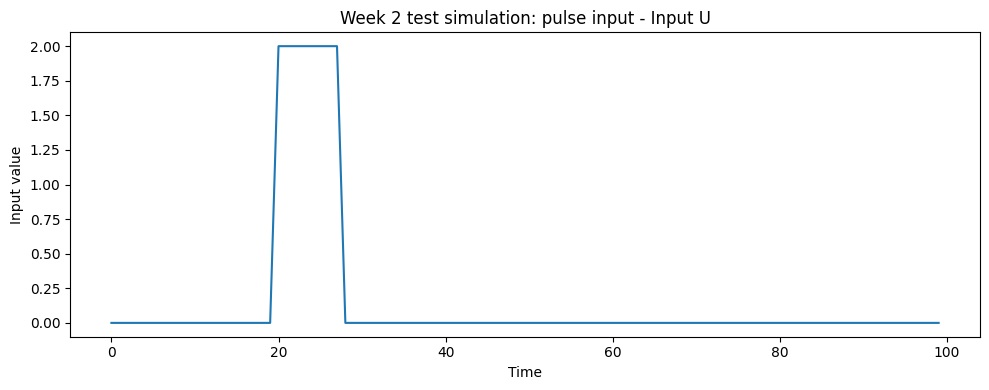

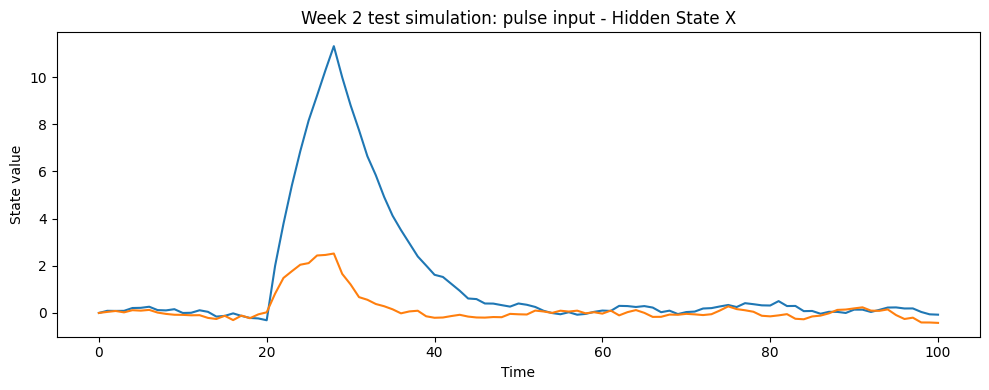

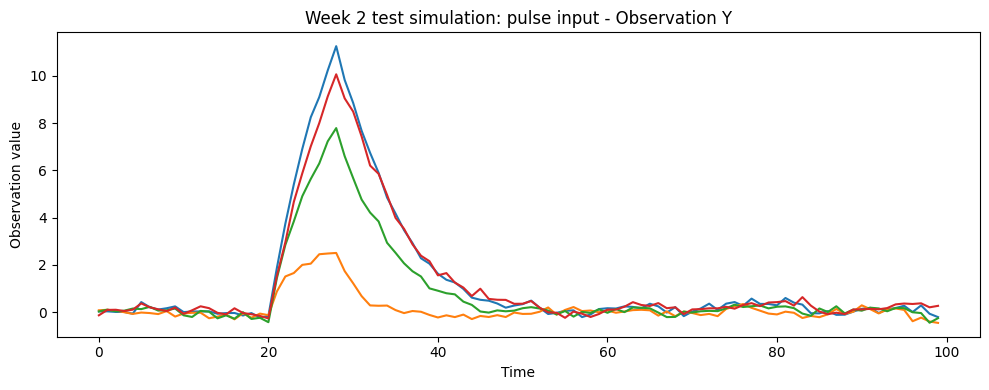

X_pulse shape: (101, 2)
Y_pulse shape: (100, 4)
U_pulse shape: (100, 1)


In [52]:
T = 100

U_pulse = sim_base.generate_input(
    T=T,
    pattern="pulse",
    amplitude=2.0,
    pulse_time=20,
    pulse_width=8,
)

result_pulse = sim_base.simulate(
    T=T,
    U=U_pulse,
    process_noise=True,
    observation_noise=True,
)

X_pulse = result_pulse["X"]
Y_pulse = result_pulse["Y"]
U_pulse = result_pulse["U"]

sim_base.plot_simulation(result_pulse, title="Week 2 test simulation: pulse input")

print("X_pulse shape:", X_pulse.shape)
print("Y_pulse shape:", Y_pulse.shape)
print("U_pulse shape:", U_pulse.shape)

In [53]:
LatentDim = sim_base.state_dim
InputDim = sim_base.input_dim

latent_hat, input_hat = est.estimate_latent_and_input(
    observation=Y_pulse,
    LatentDim=LatentDim,
    InputDim=InputDim,
)

print("Required interface check")
print("------------------------")
print("observation shape:", Y_pulse.shape)
print("latent_hat shape:", latent_hat.shape)
print("input_hat shape:", input_hat.shape)

assert latent_hat.shape == (Y_pulse.shape[0], LatentDim)
assert input_hat.shape == (Y_pulse.shape[0], InputDim)

print("Interface passed.")

Required interface check
------------------------
observation shape: (100, 4)
latent_hat shape: (100, 2)
input_hat shape: (100, 1)
Interface passed.


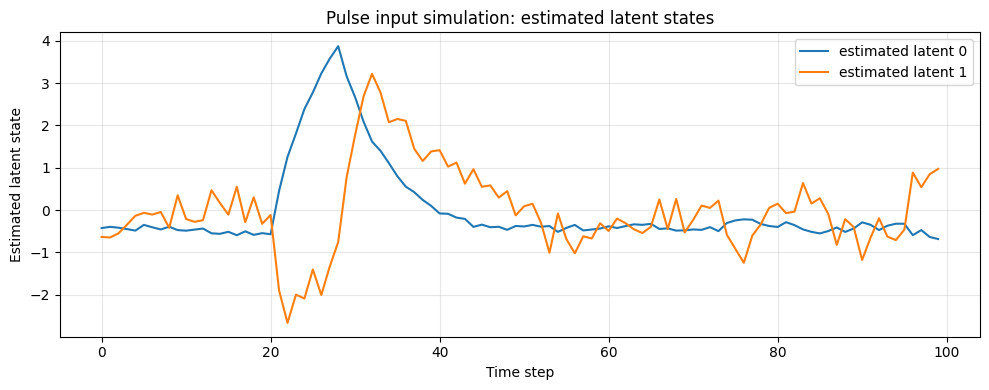

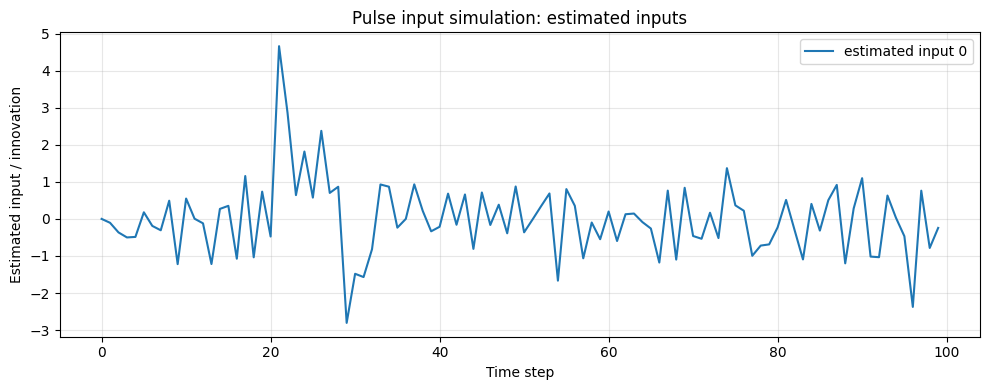

In [54]:
def plot_estimated_latent_and_input(latent_hat, input_hat, title_prefix="Estimator output"):
    T = latent_hat.shape[0]
    time = np.arange(T)

    plt.figure(figsize=(10, 4))
    for i in range(latent_hat.shape[1]):
        plt.plot(time, latent_hat[:, i], label=f"estimated latent {i}")
    plt.xlabel("Time step")
    plt.ylabel("Estimated latent state")
    plt.title(f"{title_prefix}: estimated latent states")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    for i in range(input_hat.shape[1]):
        plt.plot(time, input_hat[:, i], label=f"estimated input {i}")
    plt.xlabel("Time step")
    plt.ylabel("Estimated input / innovation")
    plt.title(f"{title_prefix}: estimated inputs")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_estimated_latent_and_input(
    latent_hat,
    input_hat,
    title_prefix="Pulse input simulation"
)

In [55]:
def align_linear(estimate, target, ridge=1e-6):
    """
    Linearly align an estimated representation to a target.

    This handles PCA sign, scale, and rotation ambiguity.

    estimate: shape (T, d_est)
    target:   shape (T, d_target)

    Returns:
        aligned estimate with shape (T, d_target)
        alignment matrix W
    """
    estimate = np.asarray(estimate, dtype=float)
    target = np.asarray(target, dtype=float)

    lhs = estimate.T @ estimate + ridge * np.eye(estimate.shape[1])
    rhs = estimate.T @ target

    try:
        W = np.linalg.solve(lhs, rhs)
    except np.linalg.LinAlgError:
        W = np.linalg.pinv(lhs) @ rhs

    aligned = estimate @ W
    return aligned, W


def mse(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return float(np.mean((a - b) ** 2))


def r2_score_simple(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0, keepdims=True)) ** 2)

    if ss_tot <= 1e-12:
        return np.nan

    return float(1.0 - ss_res / ss_tot)

Latent state evaluation after linear alignment
----------------------------------------------
Aligned latent MSE: 0.8943679119021755
Aligned latent R^2: 0.7587393945708378


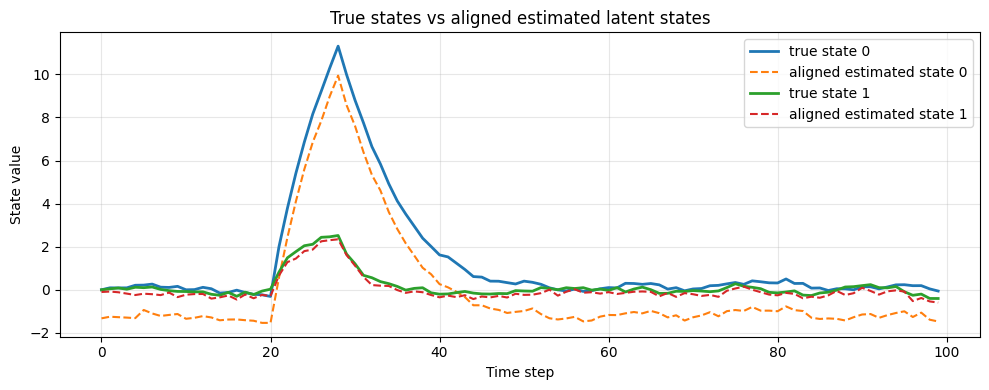

In [56]:
X_true_for_Y = X_pulse[:-1]

X_aligned, W_x = align_linear(latent_hat, X_true_for_Y)

latent_mse = mse(X_aligned, X_true_for_Y)
latent_r2 = r2_score_simple(X_true_for_Y, X_aligned)

print("Latent state evaluation after linear alignment")
print("----------------------------------------------")
print("Aligned latent MSE:", latent_mse)
print("Aligned latent R^2:", latent_r2)

time = np.arange(Y_pulse.shape[0])

plt.figure(figsize=(10, 4))
for i in range(X_true_for_Y.shape[1]):
    plt.plot(time, X_true_for_Y[:, i], label=f"true state {i}", linewidth=2)
    plt.plot(time, X_aligned[:, i], "--", label=f"aligned estimated state {i}")
plt.xlabel("Time step")
plt.ylabel("State value")
plt.title("True states vs aligned estimated latent states")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Input evaluation after linear alignment
---------------------------------------
Aligned input MSE: 0.25003663217254796
Aligned input R^2: 0.15069078745737763


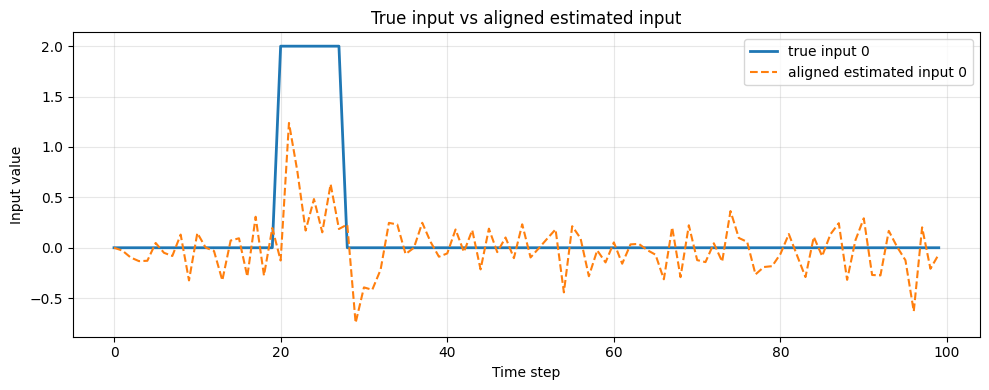

In [57]:
U_true = U_pulse

U_aligned, W_u = align_linear(input_hat, U_true)

input_mse = mse(U_aligned, U_true)
input_r2 = r2_score_simple(U_true, U_aligned)

print("Input evaluation after linear alignment")
print("---------------------------------------")
print("Aligned input MSE:", input_mse)
print("Aligned input R^2:", input_r2)

plt.figure(figsize=(10, 4))
for i in range(U_true.shape[1]):
    plt.plot(time, U_true[:, i], label=f"true input {i}", linewidth=2)
    plt.plot(time, U_aligned[:, i], "--", label=f"aligned estimated input {i}")
plt.xlabel("Time step")
plt.ylabel("Input value")
plt.title("True input vs aligned estimated input")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Noise sensitivity results
-------------------------
noise_scale=0.001 | latent MSE: 0.8478 | latent R2: 0.7699 | input MSE: 0.2423 | input R2: 0.1771
noise_scale=0.01 | latent MSE: 0.8902 | latent R2: 0.7617 | input MSE: 0.2535 | input R2: 0.1389
noise_scale=0.05 | latent MSE: 0.9798 | latent R2: 0.7475 | input MSE: 0.2644 | input R2: 0.1017
noise_scale=0.1 | latent MSE: 1.0565 | latent R2: 0.7381 | input MSE: 0.2938 | input R2: 0.0021


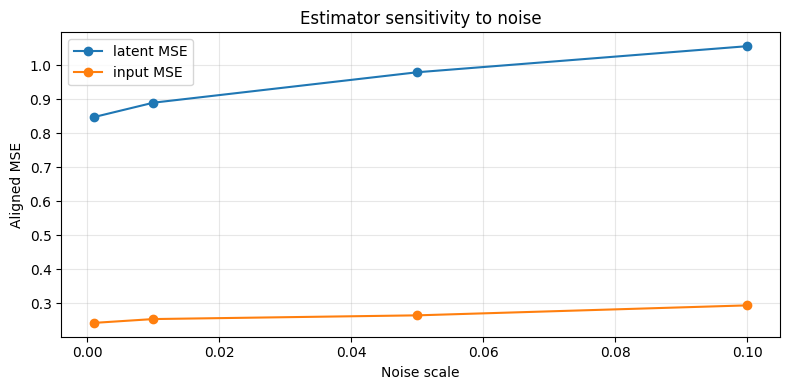

In [58]:
def evaluate_estimator_on_simulation(result, sim_obj, title=""):
    """
    Run estimator on one simulation result and compute aligned MSE/R2
    against true latent states and true inputs.
    """
    X = result["X"]
    Y = result["Y"]
    U = result["U"]

    latent_hat, input_hat = est.estimate_latent_and_input(
        observation=Y,
        LatentDim=sim_obj.state_dim,
        InputDim=sim_obj.input_dim,
    )

    # In current Simulator.py, Y[t] observes X[t].
    X_true = X[:-1]
    U_true = U

    X_aligned, _ = align_linear(latent_hat, X_true)
    U_aligned, _ = align_linear(input_hat, U_true)

    return {
        "title": title,
        "latent_hat": latent_hat,
        "input_hat": input_hat,
        "X_aligned": X_aligned,
        "U_aligned": U_aligned,
        "latent_mse": mse(X_aligned, X_true),
        "latent_r2": r2_score_simple(X_true, X_aligned),
        "input_mse": mse(U_aligned, U_true),
        "input_r2": r2_score_simple(U_true, U_aligned),
    }


noise_scales = [0.001, 0.01, 0.05, 0.10]
noise_results = []

for noise_scale in noise_scales:
    sim_noise = make_week2_baseline_system(seed=2, noise_scale=noise_scale)

    U = sim_noise.generate_input(
        T=T,
        pattern="pulse",
        amplitude=2.0,
        pulse_time=20,
        pulse_width=8,
    )

    result = sim_noise.simulate(
        T=T,
        U=U,
        process_noise=True,
        observation_noise=True,
    )

    eval_result = evaluate_estimator_on_simulation(
        result,
        sim_noise,
        title=f"noise_scale={noise_scale}",
    )

    noise_results.append(eval_result)

print("Noise sensitivity results")
print("-------------------------")
for nr in noise_results:
    print(
        nr["title"],
        "| latent MSE:", f"{nr['latent_mse']:.4f}",
        "| latent R2:", f"{nr['latent_r2']:.4f}",
        "| input MSE:", f"{nr['input_mse']:.4f}",
        "| input R2:", f"{nr['input_r2']:.4f}",
    )

plt.figure(figsize=(8, 4))
plt.plot(noise_scales, [r["latent_mse"] for r in noise_results], marker="o", label="latent MSE")
plt.plot(noise_scales, [r["input_mse"] for r in noise_results], marker="o", label="input MSE")
plt.xlabel("Noise scale")
plt.ylabel("Aligned MSE")
plt.title("Estimator sensitivity to noise")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Generalisation across input patterns
------------------------------------
pulse | latent MSE: 0.9103 | latent R2: 0.7589 | input MSE: 0.2464 | input R2: 0.1632
sine | latent MSE: 0.0501 | latent R2: 0.9849 | input MSE: 0.4444 | input R2: 0.1112
random | latent MSE: 0.1836 | latent R2: 0.8504 | input MSE: 0.5926 | input R2: 0.0011
step | latent MSE: 12.6996 | latent R2: -0.8580 | input MSE: 0.6891 | input R2: -2.2814


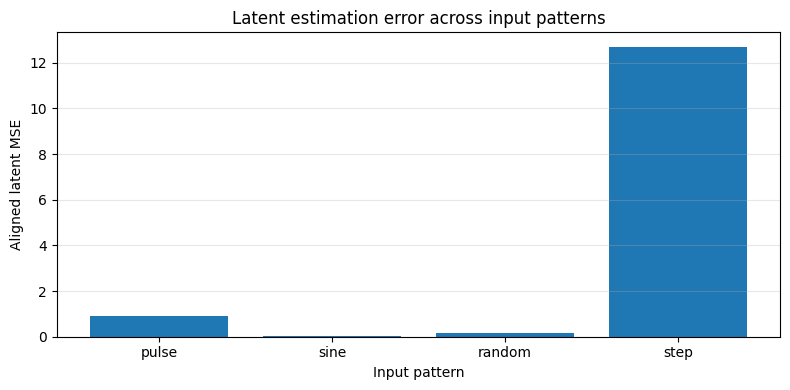

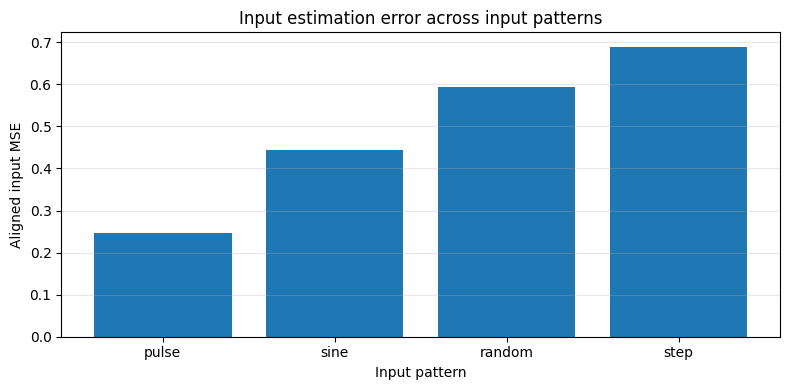

In [59]:
input_patterns = [
    ("pulse", {"amplitude": 2.0, "pulse_time": 20, "pulse_width": 8}),
    ("sine", {"amplitude": 1.0, "frequency": 0.05}),
    ("random", {"amplitude": 0.8}),
    ("step", {"amplitude": 1.0, "pulse_time": 30}),
]

pattern_results = []

sim_pattern = make_week2_baseline_system(seed=3, noise_scale=0.01)

for pattern, kwargs in input_patterns:
    U = sim_pattern.generate_input(
        T=T,
        pattern=pattern,
        **kwargs,
    )

    result = sim_pattern.simulate(
        T=T,
        U=U,
        process_noise=True,
        observation_noise=True,
    )

    eval_result = evaluate_estimator_on_simulation(
        result,
        sim_pattern,
        title=f"pattern={pattern}",
    )

    pattern_results.append((pattern, result, eval_result))

print("Generalisation across input patterns")
print("------------------------------------")
for pattern, result, er in pattern_results:
    print(
        pattern,
        "| latent MSE:", f"{er['latent_mse']:.4f}",
        "| latent R2:", f"{er['latent_r2']:.4f}",
        "| input MSE:", f"{er['input_mse']:.4f}",
        "| input R2:", f"{er['input_r2']:.4f}",
    )

plt.figure(figsize=(8, 4))
plt.bar(
    [p[0] for p in pattern_results],
    [p[2]["latent_mse"] for p in pattern_results],
)
plt.xlabel("Input pattern")
plt.ylabel("Aligned latent MSE")
plt.title("Latent estimation error across input patterns")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(
    [p[0] for p in pattern_results],
    [p[2]["input_mse"] for p in pattern_results],
)
plt.xlabel("Input pattern")
plt.ylabel("Aligned input MSE")
plt.title("Input estimation error across input patterns")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

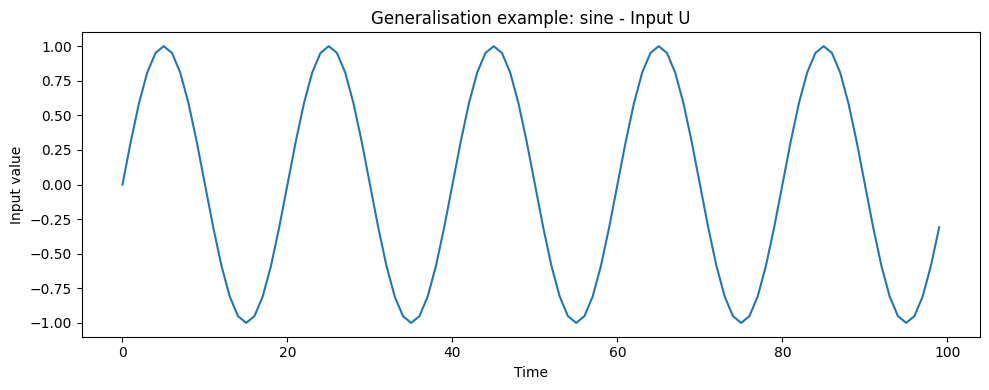

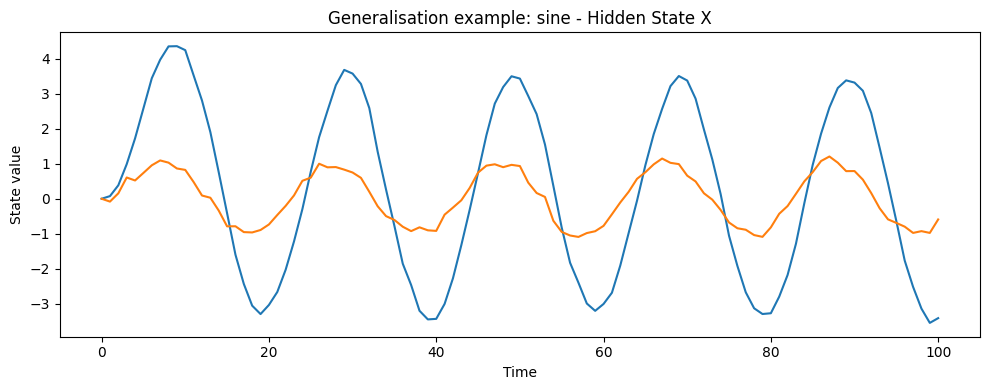

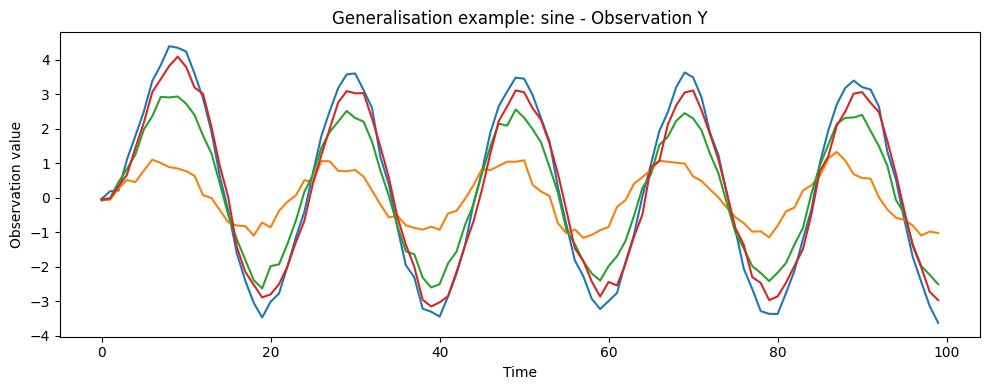

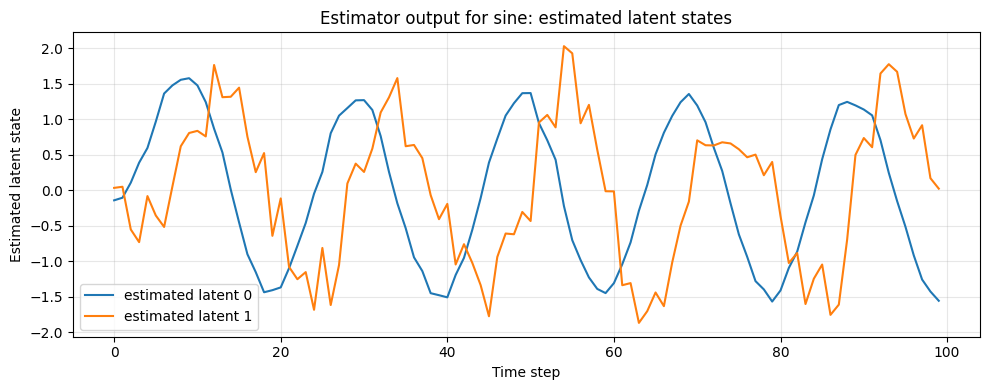

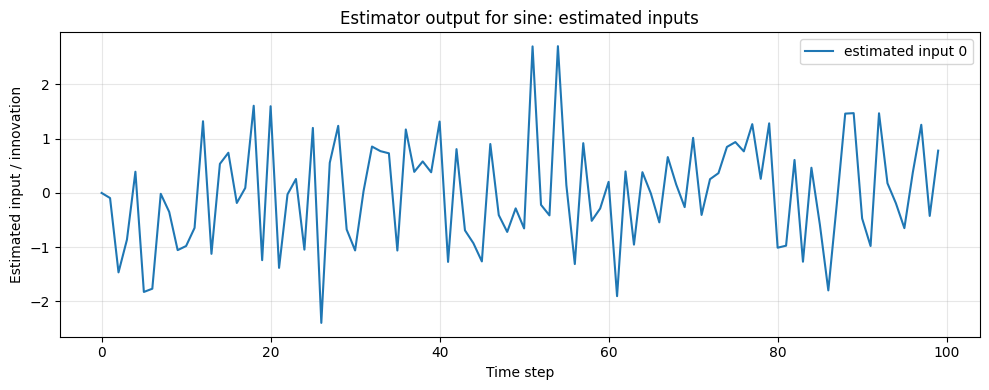

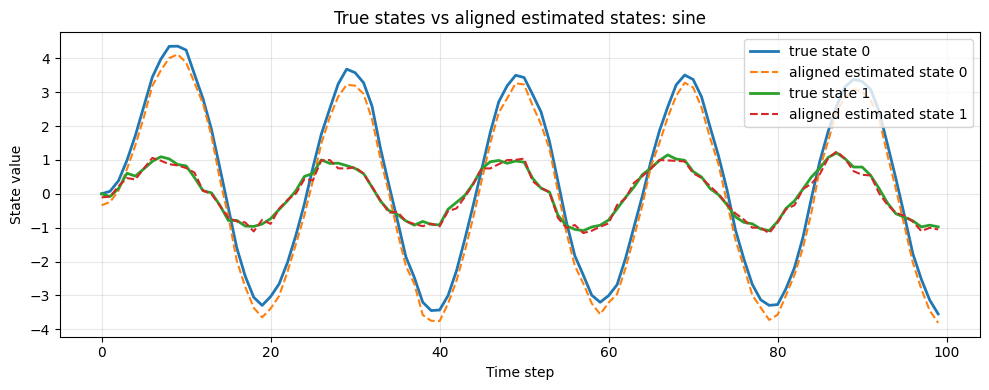

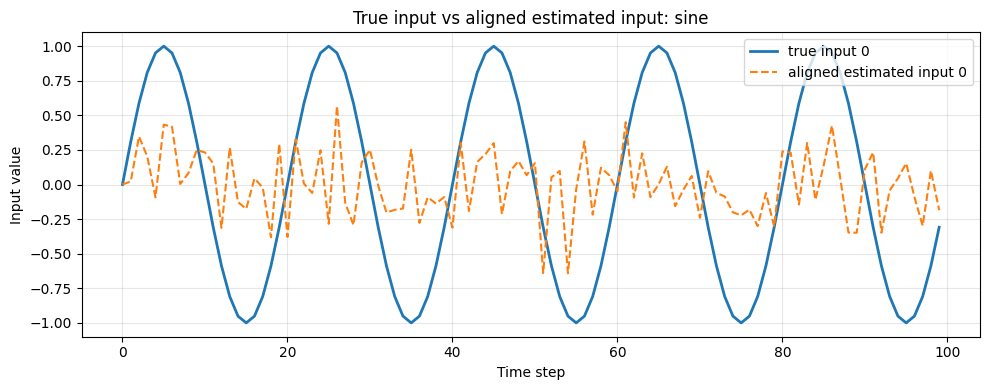

In [60]:
# Visualise one example from the input-pattern tests.
chosen_pattern = "sine"

for pattern, result, er in pattern_results:
    if pattern == chosen_pattern:
        chosen_result = result
        chosen_eval = er
        break

sim_pattern.plot_simulation(chosen_result, title=f"Generalisation example: {chosen_pattern}")

plot_estimated_latent_and_input(
    chosen_eval["latent_hat"],
    chosen_eval["input_hat"],
    title_prefix=f"Estimator output for {chosen_pattern}"
)

X_true = chosen_result["X"][:-1]
U_true = chosen_result["U"]

plt.figure(figsize=(10, 4))
for i in range(X_true.shape[1]):
    plt.plot(X_true[:, i], label=f"true state {i}", linewidth=2)
    plt.plot(chosen_eval["X_aligned"][:, i], "--", label=f"aligned estimated state {i}")
plt.xlabel("Time step")
plt.ylabel("State value")
plt.title(f"True states vs aligned estimated states: {chosen_pattern}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
for i in range(U_true.shape[1]):
    plt.plot(U_true[:, i], label=f"true input {i}", linewidth=2)
    plt.plot(chosen_eval["U_aligned"][:, i], "--", label=f"aligned estimated input {i}")
plt.xlabel("Time step")
plt.ylabel("Input value")
plt.title(f"True input vs aligned estimated input: {chosen_pattern}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ExampleDataset interface test
-----------------------------
example_observation shape: (60, 16)
ex_latent shape: (60, 2)
ex_input shape: (60, 1)


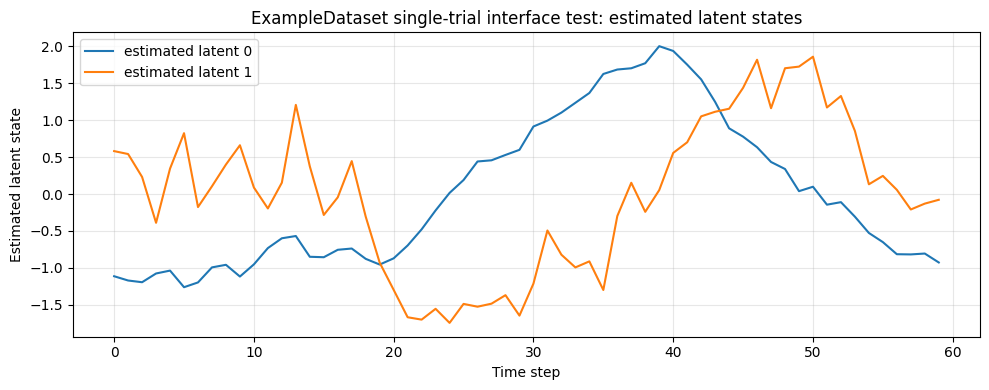

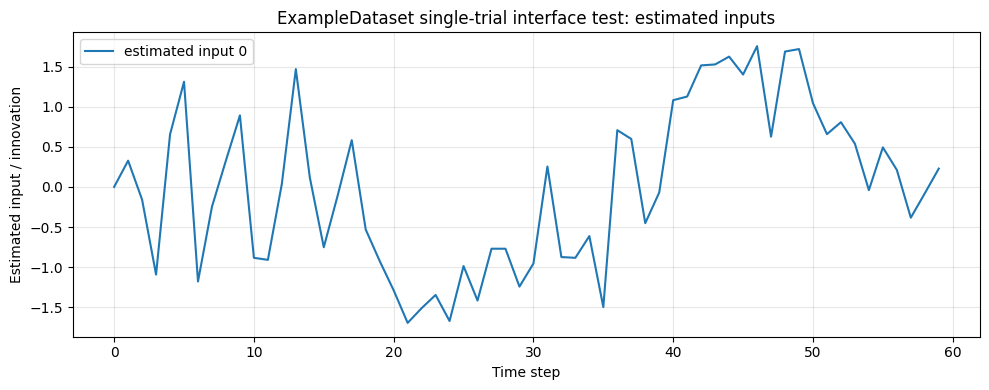

In [61]:
# Optional: test interface on ExampleDataset if available.
# This is only a format check, not training.

try:
    example_data = np.load("ExampleDataset.npy")
    example_observation = example_data[0]  # shape (Timepoints, Neurons)

    ex_latent, ex_input = est.estimate_latent_and_input(
        observation=example_observation,
        LatentDim=2,
        InputDim=1,
    )

    print("ExampleDataset interface test")
    print("-----------------------------")
    print("example_observation shape:", example_observation.shape)
    print("ex_latent shape:", ex_latent.shape)
    print("ex_input shape:", ex_input.shape)

    plot_estimated_latent_and_input(
        ex_latent,
        ex_input,
        title_prefix="ExampleDataset single-trial interface test"
    )

except FileNotFoundError:
    print("ExampleDataset.npy not found. Skipping optional format test.")